# Section 2 - Vizualization

## Certification weight: 11%

## Objectives 

- Visualize quantum circuits
- Visualize quantum measurements
- Visualize quantum states


- Visualize quantum circuits (draw circuits)
- Visualize quantum states (bloch sphere, qsphere)
- Visualize results
- Visualize devices

## Visualize quantum circuits

In [20]:
from qiskit.circuit import QuantumCircuit

qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0,1)
qc.barrier()
qc.h(2)
qc.measure_all()

By default, the draw function provides a text output

In [3]:
qc.draw()

┌───┐      ░       ░ ┌─┐      
   q_0: ┤ H ├──■───░───────░─┤M├──────
        └───┘┌─┴─┐ ░       ░ └╥┘┌─┐   
   q_1: ─────┤ X ├─░───────░──╫─┤M├───
             └───┘ ░ ┌───┐ ░  ║ └╥┘┌─┐
   q_2: ───────────░─┤ H ├─░──╫──╫─┤M├
                   ░ └───┘ ░  ║  ║ └╥┘
meas: 3/══════════════════════╩══╩══╩═
                              0  1  2

Other output formats are availlable:
- mpl
- latex

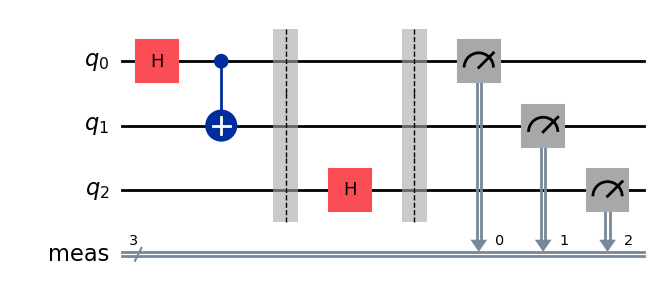

In [4]:
qc.draw("mpl")

# qc.draw(output="mpl", filename="test.jpg")     // creates a jpg file
# qc.draw("latex")                               // needs qcircuit package 

*Note:
It's possible to store default values in ~/.qiskit/settings.conf. For example, circuit_drawer = latex*

Style of the output : 
- textbook
- clifford
- iqp-dark
- bw

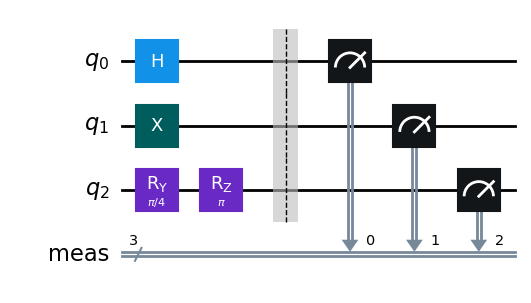

In [11]:
qc.draw(output="mpl", style="textbook")

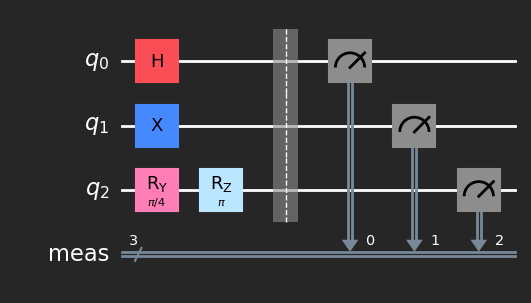

In [12]:
qc.draw(output="mpl", style="iqp-dark")

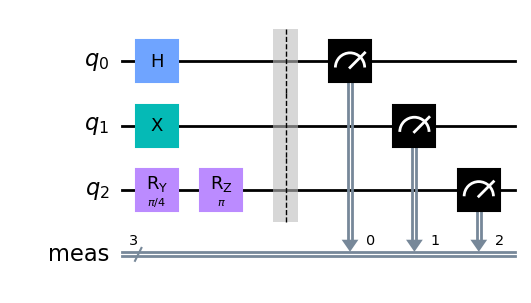

In [13]:
qc.draw(output="mpl", style="clifford")

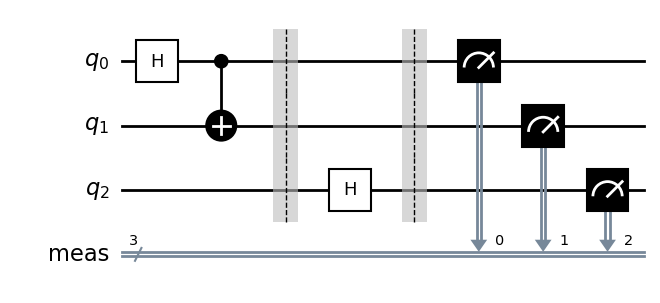

In [7]:
qc.draw(output="mpl", style="bw")

reverse_bits:

Defaults to False unless the user config file (usually ~/.qiskit/settings.conf) has an alternative value set. For example, circuit_reverse_bits = True

plot_barriers:

Disables the barriers, but keeps the arrangement (default False)

initial_state:

Displays |0> at the begining of each lines

measure_arrows:

Display the arrows between the measurement gate and the classical wire (default: True)

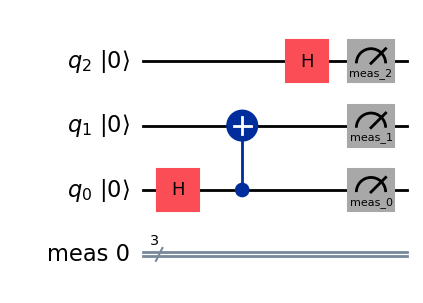

In [8]:
qc.draw("mpl", reverse_bits=True, plot_barriers=False, initial_state=True, measure_arrows=False)

fold

Sets pagination (default 25): number of gates in a line
qc.draw("mpl", pagination=10)

# Bloch sphere

Create "fake" block sphere
- using an array of three elements where [<x>, <y>, <z>] (Cartesian)
- using [<r>, <theta>, <phi>] (spherical in radians) <theta> is inclination angle from +z direction <phi> is azimuth from +x direction


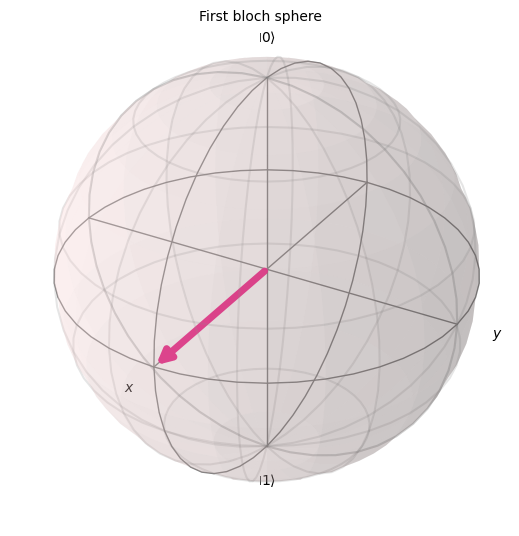

In [14]:
import numpy as np
from qiskit.visualization import plot_bloch_vector

plot_bloch_vector([1,0,0], title="First bloch sphere")

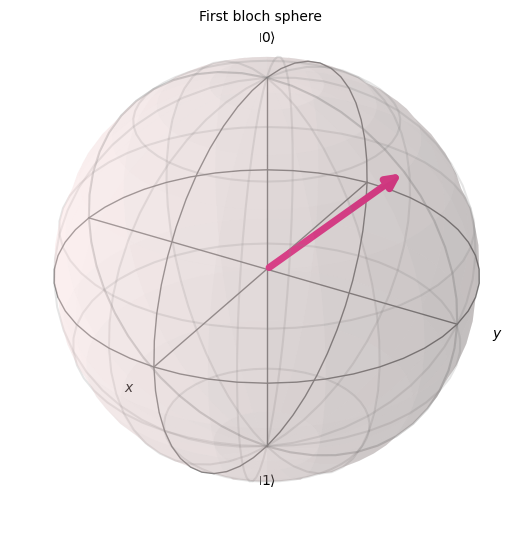

In [17]:
plot_bloch_vector([1,np.pi/4,np.pi/2], coord_type='spherical', title="First bloch sphere")

Plot a block spheres from a circuit: (doesn't work with intricated qubits)

`plot_multivector`takes a statevector or a density matrix as an input

In [37]:
qc = QuantumCircuit(3)
qc.h(0)
qc.x(1)
qc.ry(np.pi/4,2)
qc.rz(np.pi,2)
qc.draw()

┌───┐            
q_0: ───┤ H ├────────────
        ├───┤            
q_1: ───┤ X ├────────────
     ┌──┴───┴──┐┌───────┐
q_2: ┤ Ry(π/4) ├┤ Rz(π) ├
     └─────────┘└───────┘

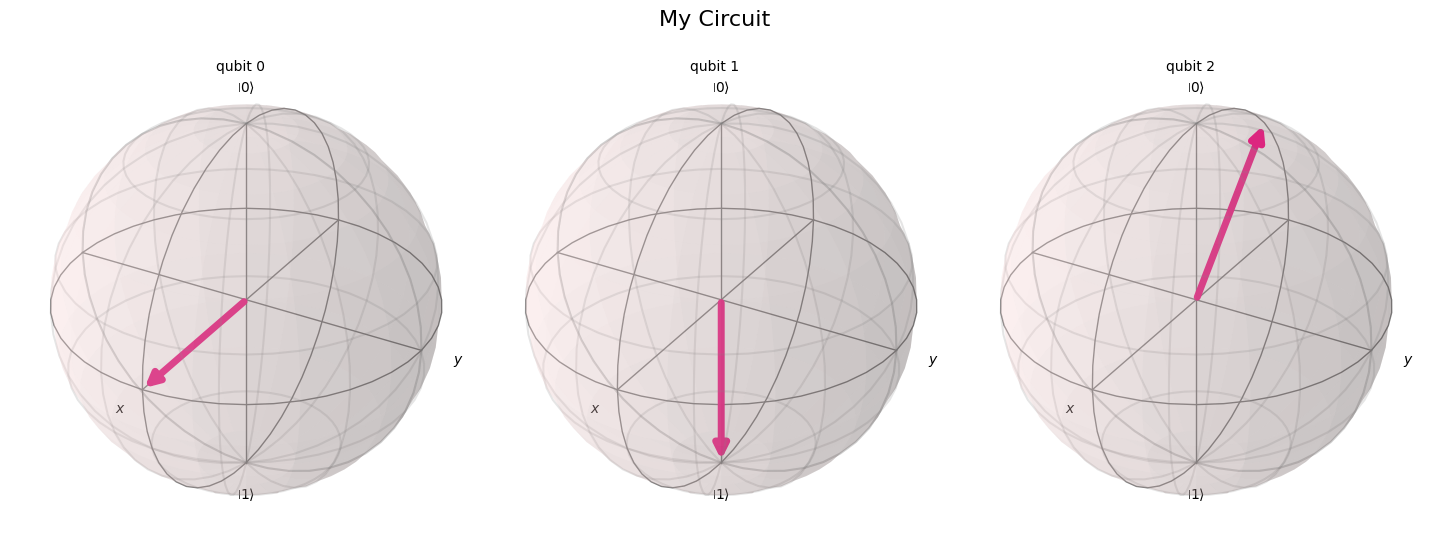

In [38]:
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
sv = Statevector.from_instruction(qc)

plot_bloch_multivector(sv, title="My Circuit")


# q-sphere

The q-sphere can represent multi-qubit states. Only the probabilities>0 are plotted.

- The dot size shows the probability of having this state
- The color shows the phase of this state
  
`plot_state_qsphere` takes a statevector or a density matrix as an input

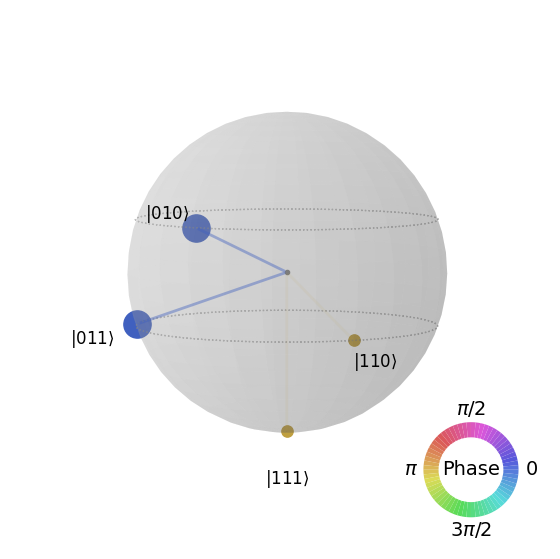

In [39]:
from qiskit.visualization import plot_state_qsphere

plot_state_qsphere(Statevector.from_instruction(qc))

## Plot a density matrix

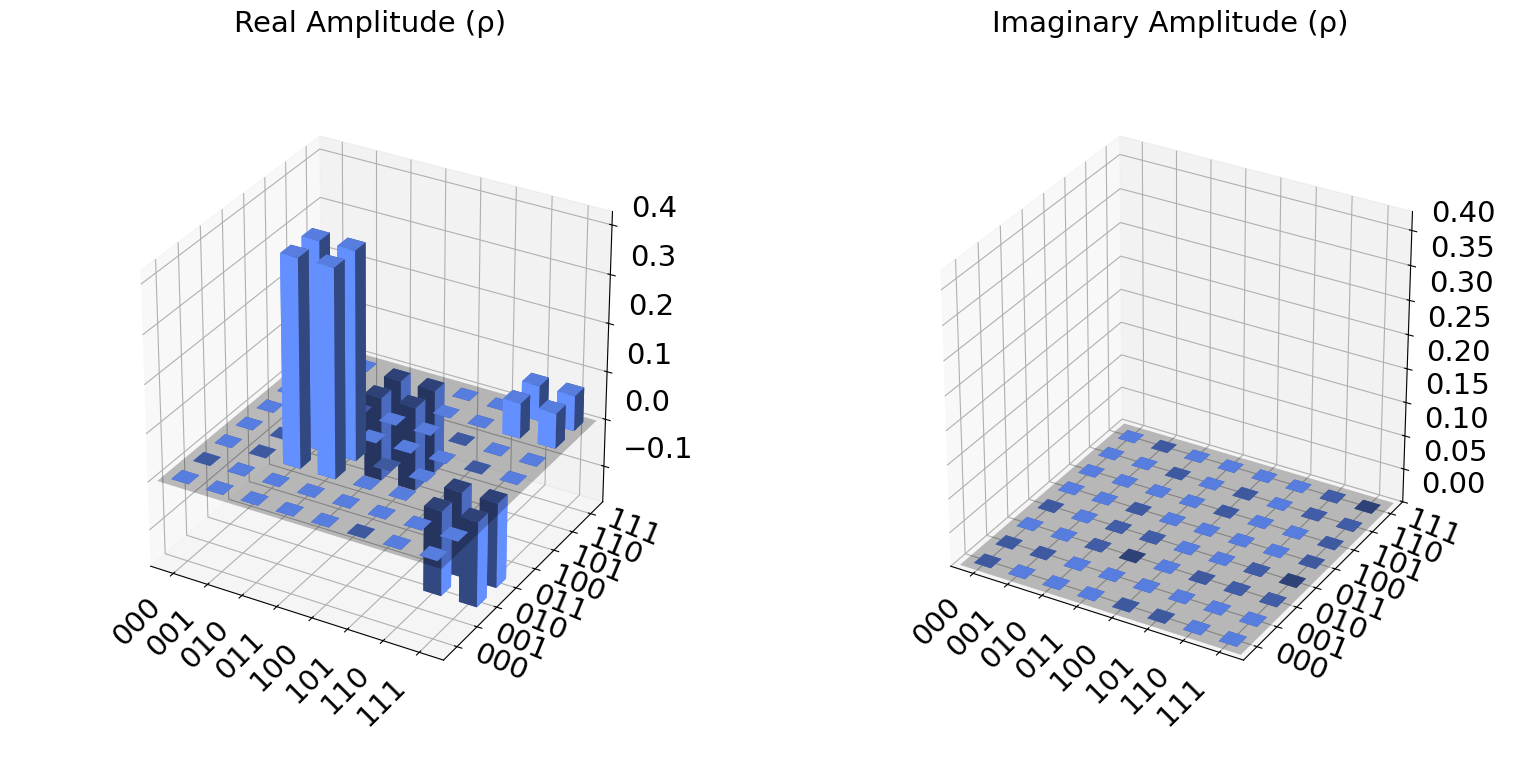

In [40]:
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_city

plot_state_city(Statevector.from_instruction(qc))

# Visualize results

In order to simplify the simulation, we'll use a fake backend

In order to visualize, measurement has to be set

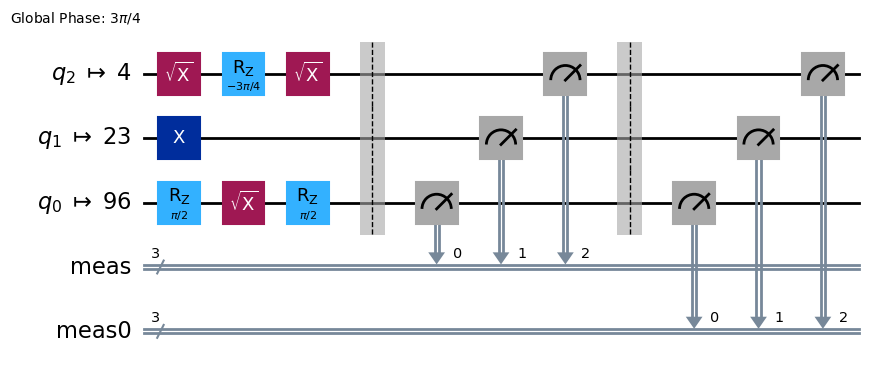

In [18]:
from qiskit import transpile
from qiskit_ibm_runtime.fake_provider import FakeFez

# Get a fake backend from the fake provider
backend = FakeFez()


# Add a measurement at the end of the circuit
qc.measure_all() 


# Transpile the ideal circuit to a circuit that can be
# directly executed by the backend



transpiled_circuit = transpile(qc, backend)
transpiled_circuit.draw('mpl')

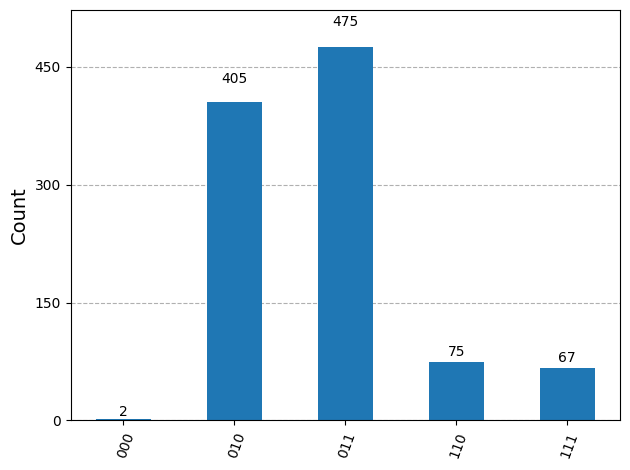

In [19]:
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import SamplerV2

sampler = SamplerV2(backend)
job = sampler.run([transpiled_circuit])
result = job.result()[0]
counts = result.data.meas.get_counts()
plot_histogram(counts)

Some visualization options can be added 

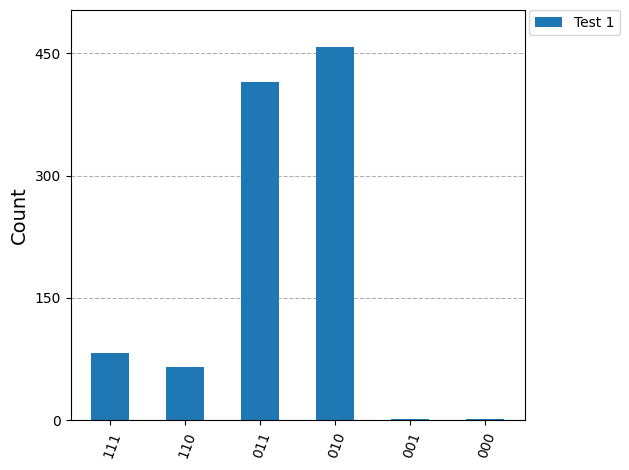

In [17]:
plot_histogram(counts, legend=["Test 1"], sort="desc", bar_labels=False)

# Visualize devices 

We can display the qubits connectivity of a device using plot_gate_map

the Graphviz library is needed (pip install graphviz && dnf install graphviz)

/usr/local/qiskit/q2.x/lib64/python3.12/site-packages/PIL/Image.py:3451: DecompressionBombWarning: Image size (177748736 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


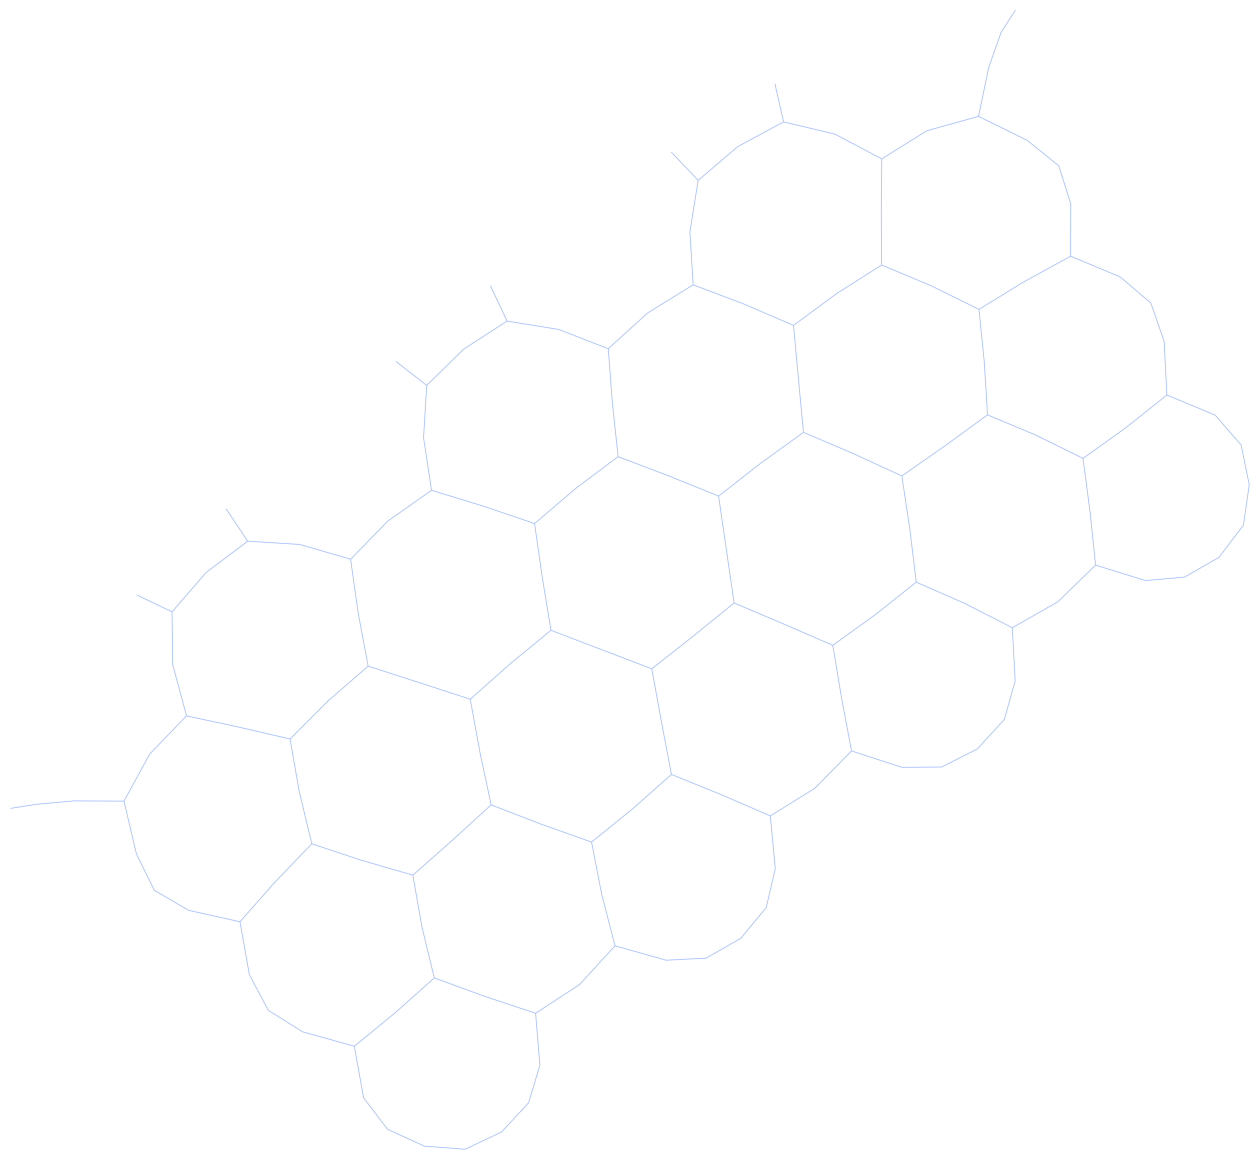

In [10]:
from qiskit.visualization import plot_gate_map
plot_gate_map(
    FakeFez(),
    figsize=(16,16),
    label_qubits=True,
    qubit_size=6,
    font_size=6
)